Problem 1: Social Network Friend Suggestion 


Friend suggestions for B: ['C']


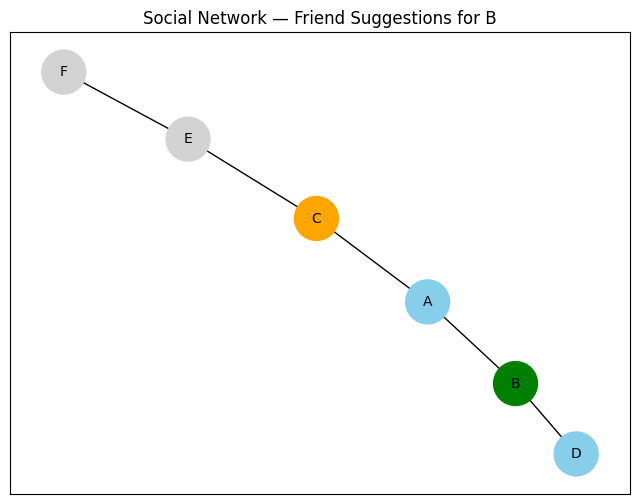

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque, defaultdict

# -----------------------------
# STEP 0 — DEFINE CONNECTIONS
# -----------------------------
connections = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("C", "E"),
    ("E", "F"),
]
# Add more pairs as needed

# Step 1: Build Graph from existing connections list
graph = defaultdict(list)
G = nx.Graph()

for u, v in connections:
    graph[u].append(v)
    graph[v].append(u)
    G.add_edge(u, v)

# Step 2: BFS-based friend suggestion
def suggest_friends(user):
    visited = set()
    queue = deque([(user, 0)])
    visited.add(user)

    direct_friends = set(graph[user])
    suggestions = set()

    while queue:
        current, level = queue.popleft()

        if level == 2:
            suggestions.add(current)
            continue

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, level + 1))

    suggestions -= direct_friends
    suggestions.discard(user)

    return list(suggestions)

# Step 3: Take user input and show suggestions
user = input("Enter user name: ")

if user not in graph:
    print("User not found in the network.")
else:
    suggested = suggest_friends(user)
    print(f"\nFriend suggestions for {user}: {suggested}")

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    node_colors = []
    for node in G.nodes():
        if node == user:
            node_colors.append('green')
        elif node in graph[user]:
            node_colors.append('skyblue')
        elif node in suggested:
            node_colors.append('orange')
        else:
            node_colors.append('lightgray')

    nx.draw_networkx(G, pos, with_labels=True, node_color=node_colors, node_size=1000, font_size=10)
    plt.title(f"Social Network — Friend Suggestions for {user}")
    plt.show()


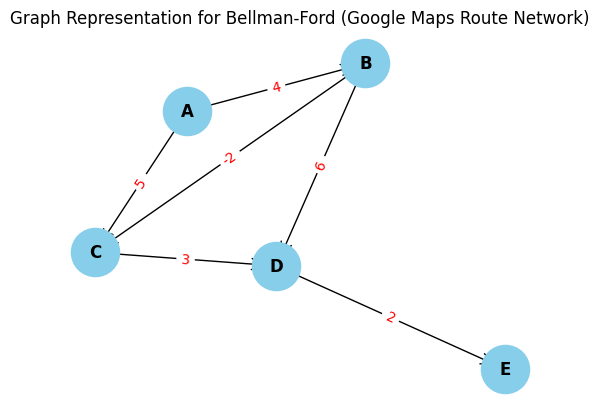

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Graph edges
edges = [
    ("A", "B", 4),
    ("A", "C", 5),
    ("B", "C", -2),
    ("B", "D", 6),
    ("C", "D", 3),
    ("D", "E", 2)
]

# Create Directed Graph
G = nx.DiGraph()

# Add edges with weights
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Generate positions for drawing
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='skyblue')

# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw edge weight labels
edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Graph Representation for Bellman-Ford (Google Maps Route Network)")
plt.axis('off')
plt.show()


Shortest distances from source: {'A': 0, 'B': 4, 'C': 2, 'D': 9, 'E': 5, 'F': 20}


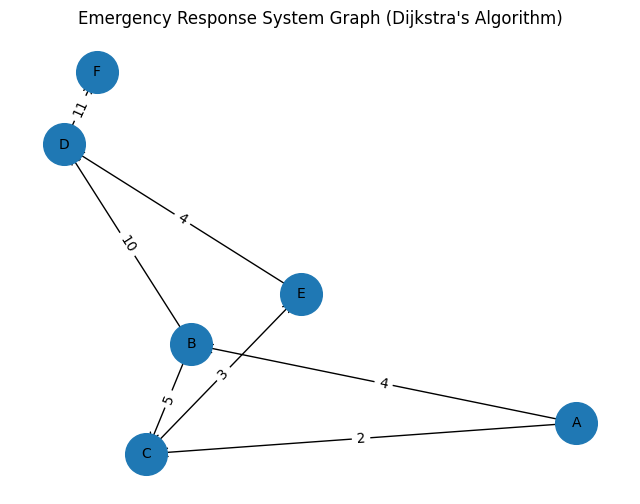

In [8]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Graph Modeling (Adjacency List)
# -----------------------------------------
graph = {
    'A': [('B', 4), ('C', 2)],
    'B': [('C', 5), ('D', 10)],
    'C': [('E', 3)],
    'D': [('F', 11)],
    'E': [('D', 4)],
    'F': []
}

# Convert adjacency list into edge list for drawing
edges = []
for u in graph:
    for v, w in graph[u]:
        edges.append((u, v, w))


# -----------------------------------------
# 2. Dijkstra’s Algorithm (Using Min-Heap)
# -----------------------------------------
def dijkstra(graph, source):
    dist = {node: float('inf') for node in graph}
    dist[source] = 0

    pq = [(0, source)]  # (distance, node)

    while pq:
        current_dist, node = heapq.heappop(pq)

        if current_dist > dist[node]:
            continue

        for neighbor, weight in graph[node]:
            new_dist = current_dist + weight
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))

    return dist


# Run Dijkstra
source = 'A'
result = dijkstra(graph, source)

print("Shortest distances from source:", result)


# -----------------------------------------
# 3. Visualizing Graph Using Matplotlib
# -----------------------------------------
G = nx.DiGraph()

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))

# Draw nodes & edges
nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=10)

# Draw weights
edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Emergency Response System Graph (Dijkstra's Algorithm)")
plt.axis('off')
plt.show()


Minimum Spanning Tree Edges:
A - C (cost = 3)
C - B (cost = 1)
B - D (cost = 2)
D - E (cost = 1)

Total Minimum Cost: 7


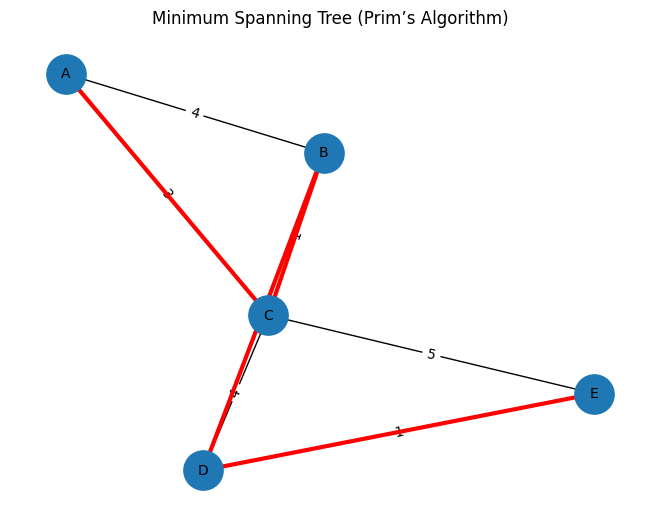

In [9]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# --------------------------
# Graph Input (Adjacency List)
# --------------------------

graph = {
    'A': [('B', 4), ('C', 3)],
    'B': [('A', 4), ('C', 1), ('D', 2)],
    'C': [('A', 3), ('B', 1), ('D', 4), ('E', 5)],
    'D': [('B', 2), ('C', 4), ('E', 1)],
    'E': [('C', 5), ('D', 1)]
}

# --------------------------
# Prim’s Algorithm
# --------------------------

def prim_mst(graph, start='A'):
    visited = set()
    min_heap = [(0, start, None)]  # (weight, node, parent)
    
    mst_edges = []
    total_cost = 0

    while min_heap:
        weight, node, parent = heapq.heappop(min_heap)

        if node in visited:
            continue

        visited.add(node)

        if parent is not None:
            mst_edges.append((parent, node, weight))
            total_cost += weight

        for neighbor, w in graph[node]:
            if neighbor not in visited:
                heapq.heappush(min_heap, (w, neighbor, node))

    return mst_edges, total_cost

mst_edges, total_cost = prim_mst(graph)

# --------------------------
# Print Result
# --------------------------

print("Minimum Spanning Tree Edges:")
for u, v, w in mst_edges:
    print(f"{u} - {v} (cost = {w})")

print("\nTotal Minimum Cost:", total_cost)

# --------------------------
# Graphical Representation
# --------------------------

G = nx.Graph()

# Add edges to original graph
for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge(node, neighbor, weight=weight)

# Plot positions
pos = nx.spring_layout(G)

# Draw full graph (light)
nx.draw(G, pos, with_labels=True, node_size=800, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))

# Highlight MST edges (bold)
mst_graph = nx.Graph()
for u, v, w in mst_edges:
    mst_graph.add_edge(u, v, weight=w)

nx.draw(
    mst_graph, pos,
    width=3,
    edge_color='red',
    with_labels=False
)

plt.title("Minimum Spanning Tree (Prim’s Algorithm)")
plt.show()
